##**Imports and Data Loading**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving WorldCupMatches.csv to WorldCupMatches.csv
Saving WorldCups.csv to WorldCups.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv("WorldCupMatches.csv" , encoding='utf-8')
cups = pd.read_csv("WorldCups.csv")

print("Data Loaded")

Data Loaded


##**World Cup matches**
###**1. Data Exploration**

In [3]:
matches.columns = matches.columns.str.strip().str.lower().str.replace(' ','_')
matches.shape
matches.head(10)
matches.tail(5)
matches.info()
matches.describe()
matches.columns.tolist()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  852 non-null    float64
 1   datetime              852 non-null    object 
 2   stage                 852 non-null    object 
 3   stadium               852 non-null    object 
 4   city                  852 non-null    object 
 5   home_team_name        852 non-null    object 
 6   home_team_goals       852 non-null    float64
 7   away_team_goals       852 non-null    float64
 8   away_team_name        852 non-null    object 
 9   win_conditions        852 non-null    object 
 10  attendance            850 non-null    float64
 11  half-time_home_goals  852 non-null    float64
 12  half-time_away_goals  852 non-null    float64
 13  referee               852 non-null    object 
 14  assistant_1           852 non-null    object 
 15  assistant_2          

['year',
 'datetime',
 'stage',
 'stadium',
 'city',
 'home_team_name',
 'home_team_goals',
 'away_team_goals',
 'away_team_name',
 'win_conditions',
 'attendance',
 'half-time_home_goals',
 'half-time_away_goals',
 'referee',
 'assistant_1',
 'assistant_2',
 'roundid',
 'matchid',
 'home_team_initials',
 'away_team_initials']

In [4]:
def audit(matches):
  summary = pd.DataFrame({
      'dtype':matches.dtypes,
      'nulls':matches.isnull().sum(),
      'null%':(matches.isnull().mean()*100).round(2),
      'unique':matches.nunique(),
      'null rows':matches.isnull().any(axis=1).sum()


  })
  return summary

audit(matches)



,dtype,nulls,null%,unique,null rows
year,float64,3720,81.36,20,3722
datetime,object,3720,81.36,602,3722
stage,object,3720,81.36,23,3722
stadium,object,3720,81.36,181,3722
city,object,3720,81.36,151,3722
home_team_name,object,3720,81.36,78,3722
home_team_goals,float64,3720,81.36,11,3722
away_team_goals,float64,3720,81.36,7,3722
away_team_name,object,3720,81.36,83,3722
win_conditions,object,3720,81.36,43,3722


###**2. Missing Values**

Empty Rows deleted


In [5]:
matches = matches.dropna(how='all')
matches = matches.reset_index(drop=True)
audit(matches)
matches.shape

(852, 20)

Filled with missing values in attendance column

In [6]:
matches['attendance'] = matches['attendance'].fillna(matches['attendance'].median())

###**3. Removing Duplicates**

In [7]:
matches.duplicated(subset=['matchid']).sum()

np.int64(16)

In [8]:
matches[matches.duplicated(keep=False)].sort_values(by=['matchid'])

,year,datetime,stage,stadium,city,home_team_name,home_team_goals,away_team_goals,away_team_name,win_conditions,attendance,half-time_home_goals,half-time_away_goals,referee,assistant_1,assistant_2,roundid,matchid,home_team_initials,away_team_initials
833,2014.0,29 Jun 2014 - 17:00,Round of 16,Arena Pernambuco,Recife,Costa Rica,1.0,1.0,Greece,Costa Rica win on penalties (5 - 3),41242.0,0.0,0.0,Ben WILLIAMS (AUS),CREAM Matthew (AUS),ANAZ Hakan (AUS),255951.0,300186459.0,CRC,GRE
839,2014.0,29 Jun 2014 - 17:00,Round of 16,Arena Pernambuco,Recife,Costa Rica,1.0,1.0,Greece,Costa Rica win on penalties (5 - 3),41242.0,0.0,0.0,Ben WILLIAMS (AUS),CREAM Matthew (AUS),ANAZ Hakan (AUS),255951.0,300186459.0,CRC,GRE
841,2014.0,30 Jun 2014 - 17:00,Round of 16,Estadio Beira-Rio,Porto Alegre,Germany,2.0,1.0,Algeria,Germany win after extra time,41579.5,0.0,0.0,RICCI Sandro (BRA),DE CARVALHO Emerson (BRA),VAN GASSE Marcelo (BRA),255951.0,300186460.0,GER,ALG
823,2014.0,30 Jun 2014 - 17:00,Round of 16,Estadio Beira-Rio,Porto Alegre,Germany,2.0,1.0,Algeria,Germany win after extra time,41579.5,0.0,0.0,RICCI Sandro (BRA),DE CARVALHO Emerson (BRA),VAN GASSE Marcelo (BRA),255951.0,300186460.0,GER,ALG
824,2014.0,04 Jul 2014 - 17:00,Quarter-finals,Estadio Castelao,Fortaleza,Brazil,2.0,1.0,Colombia,,60342.0,1.0,0.0,Carlos VELASCO CARBALLO (ESP),ALONSO FERNANDEZ Roberto (ESP),YUSTE Juan (ESP),255953.0,300186461.0,BRA,COL
845,2014.0,04 Jul 2014 - 17:00,Quarter-finals,Estadio Castelao,Fortaleza,Brazil,2.0,1.0,Colombia,,60342.0,1.0,0.0,Carlos VELASCO CARBALLO (ESP),ALONSO FERNANDEZ Roberto (ESP),YUSTE Juan (ESP),255953.0,300186461.0,BRA,COL
840,2014.0,30 Jun 2014 - 13:00,Round of 16,Estadio Nacional,Brasilia,France,2.0,0.0,Nigeria,,67882.0,0.0,0.0,GEIGER Mark (USA),HURD Sean (USA),FLETCHER Joe (CAN),255951.0,300186462.0,FRA,NGA
822,2014.0,30 Jun 2014 - 13:00,Round of 16,Estadio Nacional,Brasilia,France,2.0,0.0,Nigeria,,67882.0,0.0,0.0,GEIGER Mark (USA),HURD Sean (USA),FLETCHER Joe (CAN),255951.0,300186462.0,FRA,NGA
826,2014.0,08 Jul 2014 - 17:00,Semi-finals,Estadio Mineirao,Belo Horizonte,Brazil,1.0,7.0,Germany,,58141.0,0.0,5.0,RODRIGUEZ Marco (MEX),TORRENTERA Marvin (MEX),QUINTERO Marcos (MEX),255955.0,300186474.0,BRA,GER
848,2014.0,08 Jul 2014 - 17:00,Semi-finals,Estadio Mineirao,Belo Horizonte,Brazil,1.0,7.0,Germany,,58141.0,0.0,5.0,RODRIGUEZ Marco (MEX),TORRENTERA Marvin (MEX),QUINTERO Marcos (MEX),255955.0,300186474.0,BRA,GER


In [9]:
matches = matches.drop_duplicates().reset_index(drop=True)

###**4. Data Types**

In [10]:
matches.dtypes

,0
year,float64
datetime,object
stage,object
stadium,object
city,object
home_team_name,object
home_team_goals,float64
away_team_goals,float64
away_team_name,object
win_conditions,object


In [11]:
matches['year'] = matches['year'].astype('int')
matches['datetime'] = pd.to_datetime(matches['datetime'], errors='coerce')
matches['home_team_goals'] = matches['home_team_goals'].astype('int')
matches['away_team_goals'] = matches['away_team_goals'].astype('int')
matches['half-time_away_goals'] = matches['half-time_away_goals'].astype('int')
matches['half-time_home_goals'] = matches['half-time_home_goals'].astype('int')
matches['roundid'] = matches['roundid'].astype('int')
matches['matchid'] = matches['matchid'].astype('int')

In [12]:
matches['datetime'].isnull().sum()

np.int64(10)

In [13]:
original = pd.read_csv('WorldCupMatches.csv')


In [14]:
nat_indices = matches[matches['datetime'].isnull()].index
original.loc[nat_indices,'Datetime']

,Datetime
229,17 June 1970 - 16:00
251,22 June 1974 - 19:30
269,07 July 1974 - 16:00
588,03 June 2002 - 18:00
591,04 June 2002 - 15:30
592,04 June 2002 - 18:00
602,07 June 2002 - 18:00
605,08 June 2002 - 18:00
613,11 June 2002 - 15:30
633,17 June 2002 - 15:30


In [15]:
matches.loc[nat_indices,'datetime'] = pd.to_datetime(original.loc[nat_indices,'Datetime'].str.strip(),format='%d %B %Y - %H:%M',errors='coerce')

In [16]:
matches['datetime'].isnull().sum()

np.int64(0)

###**5.String Cleaning**

In [36]:
for col in matches.select_dtypes(include='object').columns:
  has_space_issue = (matches[col] != matches[col].str.strip()).sum()
  print(f"{col}: {has_space_issue} values with leading/trailing spaces")


stage: 0 values with leading/trailing spaces
stadium: 0 values with leading/trailing spaces
city: 0 values with leading/trailing spaces
home_team_name: 0 values with leading/trailing spaces
away_team_name: 0 values with leading/trailing spaces
win_conditions: 0 values with leading/trailing spaces
referee: 0 values with leading/trailing spaces
assistant_1: 0 values with leading/trailing spaces
assistant_2: 0 values with leading/trailing spaces
home_team_initials: 0 values with leading/trailing spaces
away_team_initials: 0 values with leading/trailing spaces


In [18]:
matches['city'] = matches['city'].str.strip()
matches['win_conditions'] = matches['win_conditions'].str.strip()

In [45]:
matches['away_team_name'].unique()

array(['Mexico', 'Belgium', 'Brazil', 'Peru', 'France', 'Bolivia',
       'Paraguay', 'Romania', 'Chile', 'USA', 'Yugoslavia', 'Argentina',
       'Egypt', 'Netherlands', 'Switzerland', 'Sweden', 'Spain',
       'Hungary', 'Austria', 'Germany', 'Czechoslovakia',
       'Dutch East Indies', 'Norway', 'Poland', 'Cuba', 'Italy',
       'England', 'Scotland', 'Turkey', 'Korea Republic', 'Germany FR',
       'Uruguay', 'Wales', 'Northern Ireland', 'Soviet Union', 'Colombia',
       'Bulgaria', 'Korea DPR', 'Portugal', 'Israel', 'Morocco',
       'El Salvador', 'Australia', 'Haiti', 'German DR', 'Zaire', 'Iran',
       'Tunisia', 'Cameroon', 'New Zealand', 'Algeria', 'Honduras',
       'Kuwait', 'Iraq', 'Denmark', 'Canada', 'Republic of Ireland',
       'United Arab Emirates', 'Costa Rica', 'Saudi Arabia', 'Russia',
       'Greece', 'Nigeria', 'South Africa', 'Japan', 'Croatia', 'Jamaica',
       'Senegal', 'Slovenia', 'Ecuador', 'China PR', 'Cote dIvoire',
       'Czech Republic', 'Ghana', 

In [44]:
matches['home_team_name'] = matches['home_team_name'].str.replace("C�te d'Ivoire",'Cote dIvoire',regex=False)
matches['away_team_name'] = matches['away_team_name'].str.replace("C�te d'Ivoire",'Cote dIvoire',regex=False)

In [20]:
fixes = {
    'Stade V\uFFFDlodrome': 'Stade Velodrome',
    'Maracan\uFFFD - Est\uFFFDdio Jornalista M\uFFFDrio Filho': 'Maracana - Estadio Jornalista Mario Filho',
    'Nou Camp - Estadio Le\uFFFDn': 'Nou Camp - Estadio Leon',
    'Estadio Jos\uFFFD Mar\uFFFDa Minella': 'Estadio Jose Maria Minella',
    'Estadio Ol\uFFFDmpico Chateau Carreras': 'Estadio Olimpico Chateau Carreras',
    'Estadio Ol\uFFFDmpico Universitario': 'Estadio Olimpico Universitario',
    'Estadio Municipal de Bala\uFFFDdos': 'Estadio Municipal de Balados'
}

matches['stadium'] = matches['stadium'].replace(fixes)

In [21]:
matches['stadium'].str.contains('\uFFFD', na=False).sum()

np.int64(0)

###**6. Outliers**

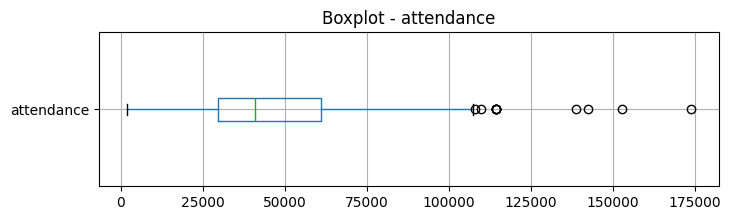

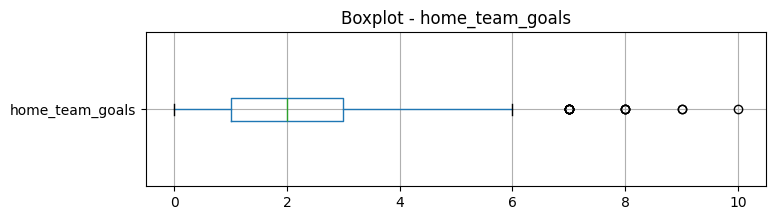

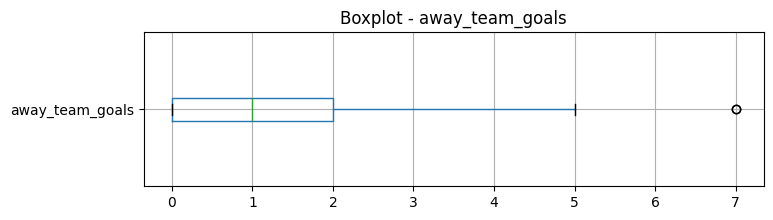

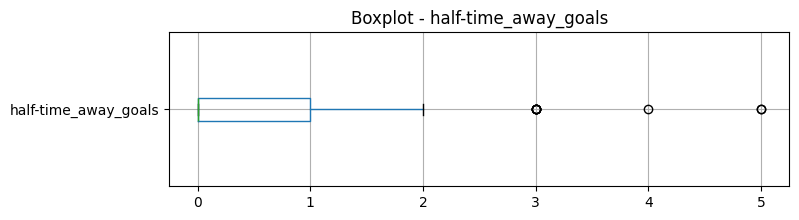

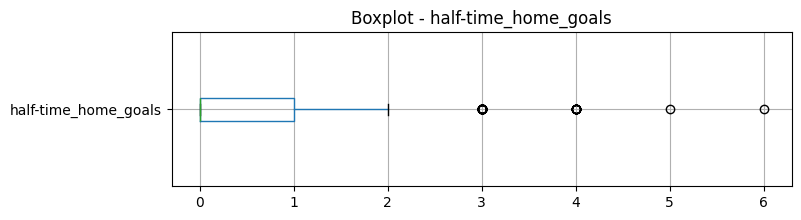

In [22]:
col_to_check = ['attendance','home_team_goals','away_team_goals','half-time_away_goals','half-time_home_goals']

for col in col_to_check:
  plt.figure(figsize=(8,2))
  matches.boxplot(column=col, vert=False)
  plt.title(f'Boxplot - {col}')
  plt.show()

IQR Method

In [23]:
for col in col_to_check:
  Q1 = matches[col].quantile(0.25)
  Q3 = matches[col].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1-1.5*IQR
  upper = Q3+1.5*IQR

  outliers = matches[(matches[col]<lower) | (matches[col]>upper)]
  print(f"{col}: {len(outliers)} outliers | lower={lower:.1f} upper={upper:.1f}")



attendance: 11 outliers | lower=-16976.8 upper=107761.2
home_team_goals: 15 outliers | lower=-2.0 upper=6.0
away_team_goals: 2 outliers | lower=-3.0 upper=5.0
half-time_away_goals: 9 outliers | lower=-1.5 upper=2.5
half-time_home_goals: 48 outliers | lower=-1.5 upper=2.5


In [33]:
matches[matches['half-time_home_goals'] > 2.5][['home_team_name','away_team_name','stage','half-time_home_goals','year']].sort_values('half-time_home_goals',ascending=False)

,home_team_name,away_team_name,stage,half-time_home_goals,year
243,Yugoslavia,Zaire,Group 2,6,1974
94,Austria,Switzerland,Quarter-finals,5,1954
13,Uruguay,Romania,Group 3,4,1930
36,Hungary,Dutch East Indies,First round,4,1938
80,Hungary,Korea Republic,Group 2,4,1954
77,Brazil,Mexico,Group 1,4,1954
66,Uruguay,Bolivia,Group 4,4,1950
46,Sweden,Cuba,Quarter-finals,4,1938
583,Germany,Saudi Arabia,Group E,4,2002
514,Sweden,Bulgaria,Match for third place,4,1994


In [46]:
matches.to_csv('WorldCupMatches_cleaned.csv',index=False)

In [47]:
from google.colab import files
files.download('WorldCupMatches_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>